# Spotify - Dataset 2009 - 2025 

## Importation des bibliothèques

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import plotly.express as px
import seaborn as sns
import openpyxl

In [4]:
%pip install pandas openpyxl

Note: you may need to restart the kernel to use updated packages.


## Chargement du fichier

In [3]:
df_spotify = pd.read_excel('Spotify.xlsx')

## Première inspection des données

In [6]:
df_spotify.head()

,track_name,track_number,track_popularity,explicit,artist_name,artist_popularity,artist_followers,artist_genres,album_name,album_release_date,album_total_tracks,album_type,track_duration_min
0,Trippy Mane (ft. Project Pat),4,0,True,Diplo,77,2812821,moombahton,"d00mscrvll, Vol. 1",2025-10-31,9,album,1.55
1,OMG!,1,0,True,Yelawolf,64,2363438,"country hip hop, southern hip hop",OMG!,2025-10-31,1,single,3.07
2,Hard 2 Find,1,4,True,Riff Raff,48,193302,NaN,Hard 2 Find,2025-10-31,1,single,2.55
3,Still Get Like That (ft. Project Pat & Starrah),8,30,True,Diplo,77,2813710,moombahton,"d00mscrvll, Vol. 1",2025-10-31,9,album,1.69
4,ride me like a harley,2,0,True,Rumelis,48,8682,dark r&b,come closer / ride me like a harley,2025-10-30,2,single,2.39


In [7]:
df_spotify.shape

(8582, 13)

## Structure du dataframe

In [8]:
df_spotify.info

<bound method DataFrame.info of                                            track_name  track_number  \
0                       Trippy Mane (ft. Project Pat)             4   
1                                                OMG!             1   
2                                         Hard 2 Find             1   
3     Still Get Like That (ft. Project Pat & Starrah)             8   
4                               ride me like a harley             2   
...                                               ...           ...   
8577                                         Big Iron             1   
8578                                          El Paso            10   
8579                                 Over the Rainbow             5   
8580                                        I'm A Man             2   
8581                               Alone And Forsaken            11   

      track_popularity  explicit    artist_name  artist_popularity  \
0                    0      True          Dip

## Données manquantes

In [9]:
df_spotify.isna().sum()

track_name               0
track_number             0
track_popularity         0
explicit                 0
artist_name              3
artist_popularity        0
artist_followers         0
artist_genres         3361
album_name               0
album_release_date       0
album_total_tracks       0
album_type               0
track_duration_min       0
dtype: int64

## Valeurs différentes dans chaque colonnes

In [10]:
df_spotify.nunique()

track_name            7462
track_number            54
track_popularity        98
explicit                 2
artist_name           2547
artist_popularity       96
artist_followers      3740
artist_genres          661
album_name            4870
album_release_date    2384
album_total_tracks      82
album_type               3
track_duration_min     647
dtype: int64

## Comprendre comment se comportent les variables numériques

In [11]:
df_spotify.describe()

,track_number,track_popularity,artist_popularity,artist_followers,album_release_date,album_total_tracks,track_duration_min
count,8582.000000,8582.000000,8582.000000,8.582000e+03,8582,8582.000000,8582.000000
mean,5.772547,52.356211,69.730016,2.403472e+07,2015-07-21 16:44:54.756467,13.789443,3.492805
min,1.000000,0.000000,0.000000,0.000000e+00,1952-09-12 00:00:00,1.000000,0.070000
25%,1.000000,39.000000,60.000000,4.623200e+05,2012-03-12 00:00:00,6.000000,2.880000
50%,4.000000,58.000000,74.000000,6.105547e+06,2018-02-14 00:00:00,13.000000,3.445000
75%,9.000000,71.000000,84.000000,2.725255e+07,2022-07-21 00:00:00,17.000000,3.990000
max,102.000000,99.000000,100.000000,1.455421e+08,2025-10-31 00:00:00,181.000000,13.510000
std,6.052792,23.816076,19.645979,3.803180e+07,NaN,11.887131,1.057970


## Vérifications des doublons

In [12]:
df_spotify.duplicated().sum()

np.int64(0)

# Questions

## **Combien d'artistes n'ont placé qu'un seul titre au sommet par rapport à ceux qui y placent régulièrement tout un album ?** 

In [13]:
df_spotify['artist_name'].unique()

<StringArray>
[                 'Diplo',               'Yelawolf',              'Riff Raff',
                'Rumelis',                 'Minzie',                 'AZERDK',
         'Toni dos Anjos',               'PsychoYP',  'What Matters The Most',
                    'A2O',
 ...
              'Link Wray',            'Ben E. King', 'Booker T. & the M.G.'s',
           'Quincy Jones',              'Dick Dale',            'Chuck Berry',
          'Marty Robbins',            'The Mystics',             'Bo Diddley',
          'Hank Williams']
Length: 2548, dtype: str

### Nombre de titres uniques par artiste au sommet

In [16]:
artist_counts = df_spotify.groupby('artist_name')['track_name'].nunique()
artist_counts

artist_name
$uicideboy$         2
'Ery Noice          1
(((())))            1
*NSYNC              1
-                   1
                   ..
攬佬SKAI ISYOURGOD    1
時瀬高等学校箏曲部           1
桑原まこ                1
梶浦 由記               1
藤澤慶昌                2
Name: track_name, Length: 2547, dtype: int64

### Artistes avec un seul titre

In [20]:
one_hit_wonders = (artist_counts == 1).sum()
one_hit_wonders

np.int64(1628)

### Artistes avec plusieurs titres (tout un album / réguliers)

In [22]:
regular_artists = (artist_counts > 1).sum()
regular_artists

np.int64(919)

### Total Artistes avec des titres 

In [26]:
total_artists = one_hit_wonders + regular_artists
total_artists

np.int64(2547)

### Calcul du ratio

In [24]:
ratio = one_hit_wonders / regular_artists if regular_artists > 0 else 0

print(f"Artistes à un seul titre : {one_hit_wonders}")
print(f"Artistes réguliers/album : {regular_artists}")
print(f"Ratio (Un seul / Plusieurs) : {ratio:.2f}")

Artistes à un seul titre : 1628
Artistes réguliers/album : 919
Ratio (Un seul / Plusieurs) : 1.77


### Calcul des pourcentages

In [29]:
pct_one_hit = (one_hit_wonders / total_artists) * 100
pct_multi_hit = (regular_artists / total_artists) * 100
print(f"Pourcentage 'Un seul titre' : {pct_one_hit:.1f}%")
print(f"Pourcentage 'Plusieurs titres/Album' : {pct_multi_hit:.1f}%\n")

Pourcentage 'Un seul titre' : 63.9%
Pourcentage 'Plusieurs titres/Album' : 36.1%



### Graphique (pie chart)

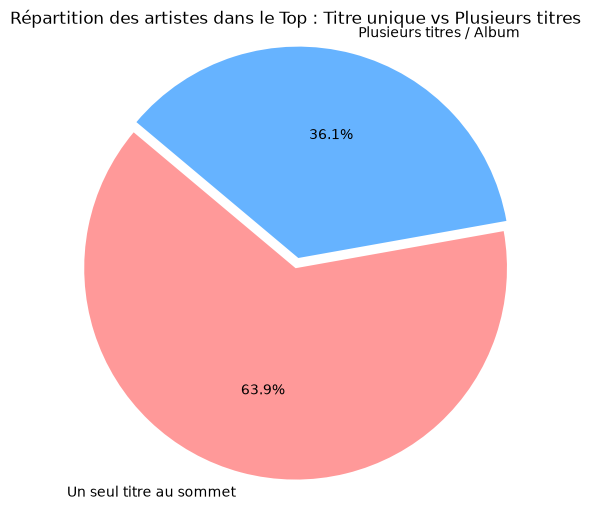

In [32]:
labels = ["Un seul titre au sommet", "Plusieurs titres / Album"]
sizes = [one_hit_wonders, regular_artists]
colors = ["#ff9999", "#66b3ff"]
explode = (0.05, 0)

plt.figure(figsize=(6, 6))
plt.pie(
    sizes,
    explode=explode,
    labels=labels,
    colors=colors,
    autopct="%1.1f%%",
    startangle=140,
)
plt.title(
    "Répartition des artistes dans le Top : Titre unique vs Plusieurs titres"
)
plt.axis("equal")  # Assure que le camembert est bien rond
plt.show()

#

## **Comment des mesures comme la « dansabilité », la « valence » (tonalité joyeuse ou triste) du Top 10 ont-elles évolué au fil des ans ? QUESTION NON PERTINENTE ICI**

In [34]:
df_spotify['artist_genres'].dropna().str.split(', ').explode().str.strip().value_counts().head(10)

artist_genres
pop                920
country            680
soundtrack         450
hip hop            431
indie              376
folk               337
rock               327
rap                297
alternative pop    228
soft pop           213
Name: count, dtype: int64

## Artiste ayant le plus de titres dans le dataset 

In [92]:
df_spotify.groupby("artist_name")["track_name"].count().sort_values(ascending=False).head(10)

artist_name
Taylor Swift         324
The Weeknd           141
Lana Del Rey          99
Ariana Grande         94
Nirvana               91
Drake                 84
Post Malone           83
The Neighbourhood     77
Lady Gaga             70
Olivia Rodrigo        68
Name: track_name, dtype: int64

## Genres uniques associés à chaque artiste 

In [91]:
df_spotify.groupby("artist_name")["artist_genres"].unique()

artist_name
$uicideboy$         [emo rap, horrorcore, cloud rap, trap metal, u...
'Ery Noice                                                      [nan]
(((())))                                                        [nan]
*NSYNC                                                          [nan]
-                                                               [nan]
                                          ...                        
攬佬SKAI ISYOURGOD                                    [chinese hip hop]
時瀬高等学校箏曲部                                        [japanese classical]
桑原まこ                                                            [nan]
梶浦 由記                                             [anime, soundtrack]
藤澤慶昌                                                          [anime]
Name: artist_genres, Length: 2547, dtype: object

#

## **La durée moyenne des morceaux a-t-elle évolué au fil des années de sortie et comment cela influencent-ils leur popularité?**

### Calcul de la durée moyenne par année

In [61]:
df_spotify.groupby('album_release_date')['track_duration_min'].mean()

album_release_date
1952-09-12    2.020
1958-01-01    2.740
1959-02-11    2.280
1959-06-30    3.430
1959-07-01    2.690
              ...  
2025-10-24    3.104
2025-10-25    2.490
2025-10-28    2.400
2025-10-30    2.944
2025-10-31    2.215
Name: track_duration_min, Length: 2384, dtype: float64

### Extraction de l'année

In [57]:
df_spotify['release_year'] = df_spotify['album_release_date'].dt.year

In [58]:
df_spotify[['album_release_date', 'release_year']].head()

,album_release_date,release_year
0,2025-10-31,2025
1,2025-10-31,2025
2,2025-10-31,2025
3,2025-10-31,2025
4,2025-10-30,2025


### Classement en fonction de la popularité

In [66]:
df_spotify['popularity_group'] = pd.cut(
    df_spotify['track_popularity'],
    bins=[0, 20, 40, 60, 80, 100],
    labels=['Très faible', 'Faible', 'Moyenne', 'Élevée', 'Très élevée'])

In [67]:
df_spotify.groupby('popularity_group', observed=True)['track_duration_min'].mean()

popularity_group
Très faible    3.455414
Faible         3.317332
Moyenne        3.443084
Élevée         3.601175
Très élevée    3.665490
Name: track_duration_min, dtype: float64

### Durée moyenne d'une chanson

In [5]:
duree_moyenne = np.mean(df_spotify['track_duration_min'])
duree_moyenne

np.float64(3.492804707527383)

### Durée moyenne d'une chanson par année

In [12]:
duree_par_annee = df_spotify.groupby('album_release_date')['track_duration_min'].mean().reset_index()
duree_par_annee

,album_release_date,track_duration_min
0,1952-09-12,2.020
1,1958-01-01,2.740
2,1959-02-11,2.280
3,1959-06-30,3.430
4,1959-07-01,2.690
...,...,...
2379,2025-10-24,3.104
2380,2025-10-25,2.490
2381,2025-10-28,2.400
2382,2025-10-30,2.944


### Graphique (bar chart)

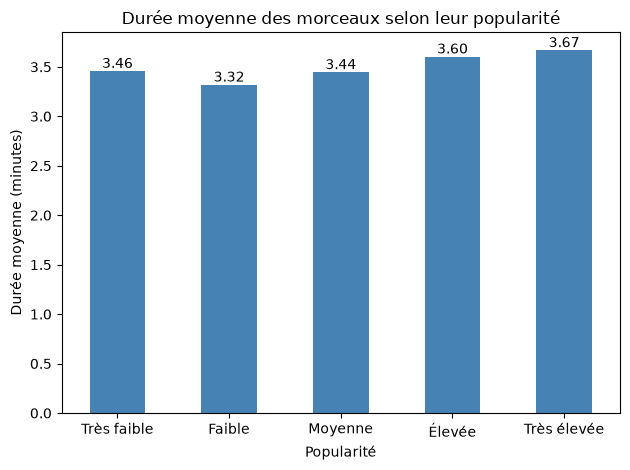

In [69]:
ax = df_spotify.groupby(
    'popularity_group',
    observed=True
)['track_duration_min'].mean().plot(
    kind='bar',
    color='steelblue'
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')

plt.xlabel('Popularité')
plt.ylabel('Durée moyenne (minutes)')
plt.title('Durée moyenne des morceaux selon leur popularité')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


### Distribution des durées par décennies

In [25]:
df_spotify['decennie'] = (df_spotify['album_release_date'].dt.year // 10) * 10

### Graphique (boxplot)

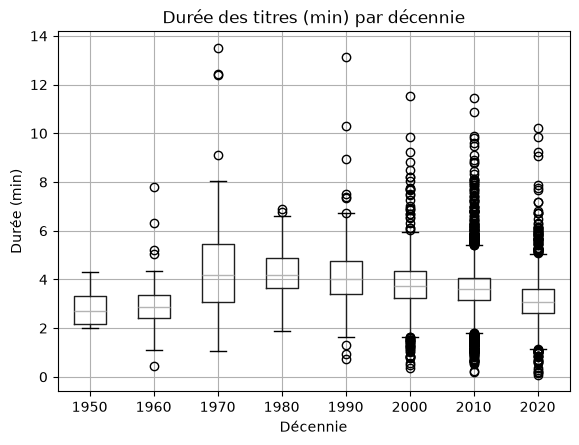

In [23]:
df_spotify.boxplot(column='track_duration_min', by='decennie')

plt.suptitle('')
plt.title('Durée des titres (min) par décennie')
plt.xlabel('Décennie')
plt.ylabel('Durée (min)')
plt.show()

#

## **Les titres sortis en hiver ou en été sont-ils le plus dans le top du classement ?**

### Extraction du mois

In [75]:
df_spotify['release_month'] = df_spotify['album_release_date'].dt.month

### Association des mois avec les saisons

In [76]:
def assigner_saison(mois):
    if mois in [12, 1, 2]:
        return 'Hiver'
    elif mois in [3, 4, 5]:
        return 'Printemps'
    elif mois in [6, 7, 8]:
        return 'Été'
    elif mois in [9, 10, 11]:
        return 'Automne'

df_spotify['saison'] = df_spotify['release_month'].apply(assigner_saison)

### Vérification

In [77]:
df_spotify.columns.tolist()

['track_name',
 'track_number',
 'track_popularity',
 'explicit',
 'artist_name',
 'artist_popularity',
 'artist_followers',
 'artist_genres',
 'album_name',
 'album_release_date',
 'album_total_tracks',
 'album_type',
 'track_duration_min',
 'release_year',
 'popularity_group',
 'release_month',
 'saison']

### Top des titres (plus de 70%)

In [87]:
(df_spotify['track_popularity'] >= 70).sum()

np.int64(2373)

In [78]:
top_titres = df_spotify[df_spotify['track_popularity'] >= 70]
top_titres['saison'].value_counts()

saison
Automne      663
Été          626
Printemps    604
Hiver        480
Name: count, dtype: int64

### Graphique

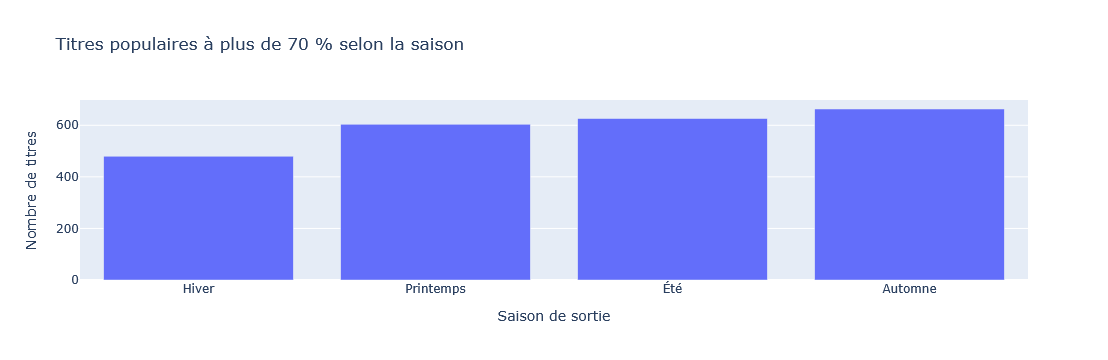

In [88]:
saisons_top = (
    df_spotify[df_spotify['track_popularity'] >= 70]['saison']
    .value_counts()
    .reindex(['Hiver', 'Printemps', 'Été', 'Automne'])
    .dropna()
)

fig = px.bar(
    x=saisons_top.index,
    y=saisons_top.values,
    labels={
        'x': 'Saison de sortie',
        'y': 'Nombre de titres'
    },
    title='Titres populaires à plus de 70 % selon la saison')
fig.show()

#

## **Quelle est la proportion de titres explicit dans le dataset, quel type d’album (type et genre) contient la plus grande proportion de titres explicit, et est-ce que leur popularité moyenne diffère-t-elle de celle des titres non-explicit ?**

### Mesures de base (1) - Moyenne de popularité

In [103]:
moyenne = np.mean(df_spotify["track_popularity"])
moyenne

np.float64(52.35621067350268)

### Mesures de base (2) - Médiane de popularité

In [104]:
mediane = np.median(df_spotify["track_popularity"])
mediane

np.float64(58.0)

### Mesures de base (3) - Écart type de popularité

In [106]:
ecart_type = np.std(df_spotify["track_popularity"])
ecart_type

np.float64(23.814688091770346)

### Séparation des titres "Non-explicit" et "Explicit"

In [125]:
explicit = df_spotify[df_spotify["explicit"] == True]["track_popularity"]
non_explicit = df_spotify[df_spotify["explicit"] == False]["track_popularity"]
non_explicit

5        2
6       20
7       27
8       16
10      30
        ..
8577    71
8578    64
8579     8
8580    55
8581    45
Name: track_popularity, Length: 6434, dtype: int64

### Proportion de titres "Explicit" (en pourcentage) ← **Chiffre clé**

In [108]:
df_spotify["explicit"].value_counts(normalize=True) * 100

explicit
False    74.970869
True     25.029131
Name: proportion, dtype: float64

### Proportion de titres "Explicit" (en pourcentage - NumPy)

In [96]:
np.mean(df_spotify["explicit"]) * 100

np.float64(25.029130738755534)

### Nombre de titres "Explicit" (en titres distinct - NumPy) ← **Chiffre clé**

In [110]:
nombre_explicit = np.sum(df_spotify['explicit'])
nombre_explicit

np.int64(2148)

### Moyenne de popularité des titres "Explicit"

In [131]:
moyenne_explicit = np.mean(explicit)
moyenne_explicit

np.float64(57.81843575418994)

### Moyenne de popularité des titres "Non-explicit"

In [130]:
moyenne_non_explicit = np.mean(non_explicit)
moyenne_non_explicit

np.float64(50.53263910475599)

### Popularité des titres "Explicit" ← **Chiffre clé**

In [136]:
df_spotify.groupby("explicit")["track_popularity"].mean()

explicit
False    50.532639
True     57.818436
Name: track_popularity, dtype: float64

### Quel type de chanson (single/ album/ compilation) contient la plus grande proportion de titres "Explicit" (en pourcentage)

In [145]:
df_spotify.groupby("album_type")["explicit"].mean() * 100

album_type
album          26.314891
compilation     7.297830
single         25.687247
Name: explicit, dtype: float64

### Quel type de chanson (single/ album/ compilation) contient la plus grande proportion de titres "Explicit" (en pourcentage - NumPy)

In [8]:
#np.mean(df_spotify.groupby("album_type")["explicit"]) * 100 = mon erreur du début
proportion_explicit = df_spotify.groupby("album_type")["explicit"].apply(np.mean) * 100
proportion_explicit

album_type
album          26.314891
compilation     7.297830
single         25.687247
Name: explicit, dtype: float64

### Nombre total de chansons dans de dataset

In [148]:
nombre_total_type = df_spotify.groupby("album_type")["track_name"].count()
nombre_total_type

album_type
album          5856
compilation     507
single         2219
Name: track_name, dtype: int64

### Quel type de chanson (single/ album/ compilation) contient la plus grande proportion de titres "Explicit" (en titres distinct - NumPy)

In [147]:
nombre_explicit_type = df_spotify.groupby("album_type")["explicit"].apply(np.sum)
nombre_explicit_type

album_type
album          1541
compilation      37
single          570
Name: explicit, dtype: int64

### Graphique (bar chart)

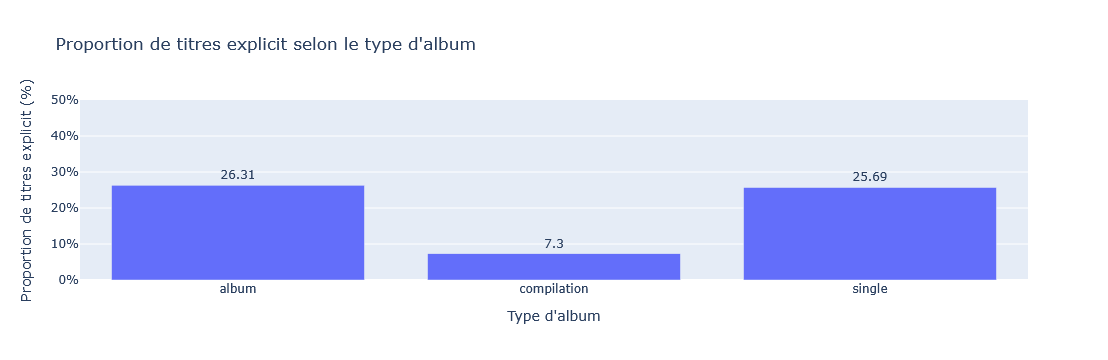

In [7]:
proportion_album = df_spotify.groupby("album_type")["explicit"].mean() * 100

fig = px.bar(
    x=proportion_album.index,
    y=proportion_album.values,
    labels={"x": "Type d'album","y": "Proportion de titres explicit (%)"},
    title="Proportion de titres explicit selon le type d'album",
    text=proportion_album.values.round(2))

fig.update_traces(textposition="outside",hovertemplate="%{x}<br>Proportion explicit : %{y:.2f}%<extra></extra>")

fig.update_yaxes(
    range=[0, 50],
    ticksuffix="%")

fig.show()


### Isolation de la variable des albums

In [151]:
albums_isolation = df_spotify[df_spotify["album_type"] == "album"]
albums_isolation.head(5)

,track_name,track_number,track_popularity,explicit,artist_name,artist_popularity,artist_followers,artist_genres,album_name,album_release_date,album_total_tracks,album_type,track_duration_min,release_year,popularity_group,release_month,saison
0,Trippy Mane (ft. Project Pat),4,0,True,Diplo,77,2812821,moombahton,"d00mscrvll, Vol. 1",2025-10-31,9,album,1.55,2025,NaN,10,Automne
3,Still Get Like That (ft. Project Pat & Starrah),8,30,True,Diplo,77,2813710,moombahton,"d00mscrvll, Vol. 1",2025-10-31,9,album,1.69,2025,Faible,10,Automne
11,PAPARAZZI ARRIVE - English Ver.,1,48,False,A2O,46,13826,c-pop,PAPARAZZI ARRIVE,2025-10-24,14,album,2.89,2025,Moyenne,10,Automne
12,Root of all Evil,5,65,False,Daniel Caesar,85,11137714,NaN,Son Of Spergy,2025-10-24,12,album,4.41,2025,Élevée,10,Automne
14,MELODY - CHENYU & SHIJIE & QUCHANG,11,27,False,A2O,46,13590,c-pop,PAPARAZZI ARRIVE,2025-10-24,14,album,4.25,2025,Faible,10,Automne


### Séparation Explicit / Non-explicit

In [154]:
albums_explicit = albums_isolation[albums_isolation["explicit"] == True]["track_duration_min"]
albums_non_explicit = albums_isolation[albums_isolation["explicit"] == False]["track_duration_min"]
albums_explicit
albums_non_explicit

11      2.89
12      4.41
14      4.25
17      2.92
25      3.26
        ... 
8576    2.05
8577    3.92
8578    4.32
8580    2.74
8581    2.02
Name: track_duration_min, Length: 4315, dtype: float64

### Calcul durée moyenne (avec NumPy)

In [155]:
moyenne_explicit = np.mean(albums_explicit)
moyenne_non_explicit = np.mean(albums_non_explicit)

print("Durée moyenne des chansons explicit :", moyenne_explicit)
print("Durée moyenne des chansons non-explicit :", moyenne_non_explicit)

Durée moyenne des chansons explicit : 3.6348864373783263
Durée moyenne des chansons non-explicit : 3.622375434530707


### Différence entre les deux

In [157]:
difference = moyenne_explicit - moyenne_non_explicit
print("Différence de durée :", difference, "minutes")

Différence de durée : 0.012511002847619412 minutes


### Graphique Proportion titre explicit (à refaire)

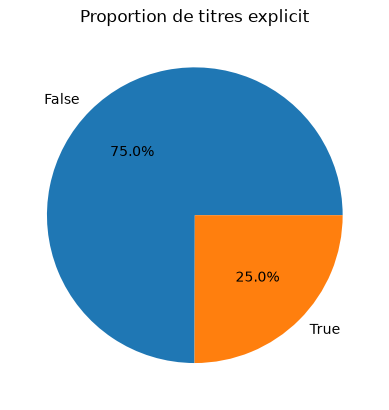

In [5]:
df_spotify["explicit"].value_counts().plot(
    kind="pie", autopct="%1.1f%%", colors=["#1f77b4", "#ff7f0e"]
)
plt.title("Proportion de titres explicit")
plt.show()

<Axes: xlabel='explicit'>

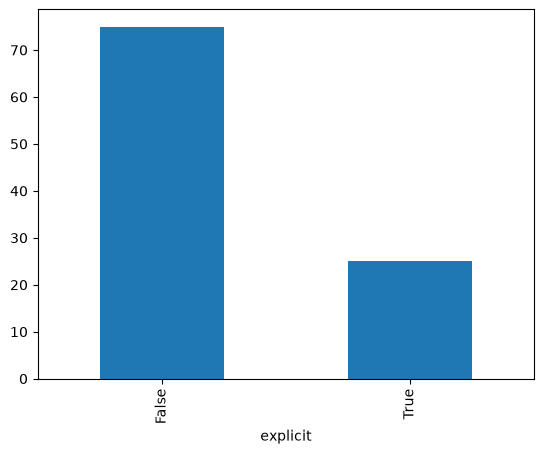

In [4]:
proportion = df_spotify["explicit"].value_counts(normalize=True) * 100

proportion.plot(kind="bar")

### Graphique Popularité explicit vs non-explicit

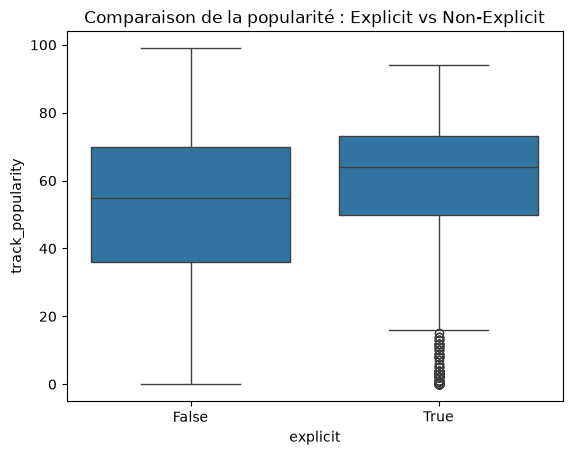

In [10]:
sns.boxplot(data=df_spotify, x="explicit", y="track_popularity")
plt.title("Comparaison de la popularité : Explicit vs Non-Explicit")
plt.show()

### Proportion de genres explicit ← **Chiffre clé**

In [13]:
proportion_genre = (
    df_spotify.groupby("artist_genres")["explicit"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

proportion_genre

artist_genres
uk drill, drill, grime, uk grime, afroswing              100.0
uk drill, drill, grime, uk grime                         100.0
trap soul                                                100.0
trap metal, horrorcore, emo rap, cloud rap, rap metal    100.0
trap                                                     100.0
                                                         ...  
alternative metal, post-grunge, rock, hard rock            0.0
alternative metal                                          0.0
texas country, country, red dirt                           0.0
techengue, latin house                                     0.0
afrobeats                                                  0.0
Name: explicit, Length: 661, dtype: float64

### Catégorisation par genres

In [16]:
genres_avec_explicit = np.sum(proportion_genre > 0)
genres_avec_explicit

np.int64(196)

In [17]:
genres_sans_explicit = np.sum(proportion_genre == 0)
genres_sans_explicit

np.int64(465)

### Pourcentage par genres

In [19]:
total_genres = len(proportion_genre)
pourcentage_avec = genres_avec_explicit / total_genres * 100
pourcentage_avec

np.float64(29.652042360060516)

In [20]:
pourcentage_sans = genres_sans_explicit / total_genres * 100
pourcentage_sans

np.float64(70.34795763993948)

### Graphique 1 : Genre explicit vs genre non-explicit

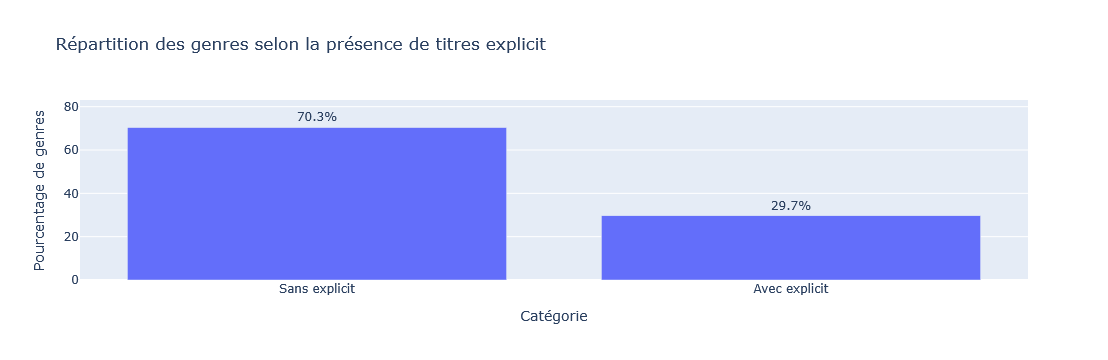

In [23]:
fig = px.bar(
    x=["Sans explicit", "Avec explicit"],
    y=[pourcentage_sans, pourcentage_avec],
    text=[f"{pourcentage_sans:.1f}%", f"{pourcentage_avec:.1f}%"],
    title="Répartition des genres selon la présence de titres explicit",
    labels={"x": "Catégorie", "y": "Pourcentage de genres"}
)

fig.update_traces(textposition="outside")
fig.show()


### Top 10 des genres avec la plus fortes proportions d'explicit ← **Chiffre clé**

In [25]:
genres_avec_explicit = proportion_genre[proportion_genre > 0]
top_10 = genres_avec_explicit.sort_values(ascending=False).head(10)
top_10

artist_genres
uk drill, drill, grime, uk grime, afroswing              100.0
uk drill, drill, grime, uk grime                         100.0
trap soul                                                100.0
trap metal, horrorcore, emo rap, cloud rap, rap metal    100.0
trap                                                     100.0
alté, nigerian drill, afrobeats, afrobeat                100.0
alté                                                     100.0
southern hip hop, crunk                                  100.0
southern hip hop, hip hop                                100.0
southern hip hop, rap, trap                              100.0
Name: explicit, dtype: float64

### Nombre de chansons par genre

In [29]:
nombre_titres = df_spotify.groupby("artist_genres")["track_name"].count()
nombre_titres

artist_genres
3 step, gqom                                              1
acid house                                                1
acid techno, techno, hard techno, tekno                   1
afro house                                                4
afro house, house, afro tech                              1
                                                         ..
witch house, electroclash, new rave, alternative dance    4
worship, christian, ccm                                   1
yacht rock                                                2
yacht rock, soft rock                                     1
yacht rock, soft rock, folk rock                          1
Name: track_name, Length: 661, dtype: int64

### Proportion par genre de l'artiste

In [31]:
proportion_genre_filtre = proportion_genre[nombre_titres >= 50]
top_10 = proportion_genre_filtre[proportion_genre_filtre > 0].sort_values(ascending=False).head(10)
top_10

artist_genres
emo rap, cloud rap                              98.387097
rap, hip hop                                    96.000000
rap                                             87.700535
reggaeton, trap latino, urbano latino, latin    80.357143
pop, hip hop, country                           71.084337
r&b pop, alternative r&b, hip hop, synthpop     49.645390
r&b                                             46.153846
pop rock, alternative pop, pop punk             36.764706
dark r&b                                        36.363636
pop, r&b                                        32.692308
Name: explicit, dtype: float64

### Graphique 2 : Top 10 des genres explicit (bar chart)

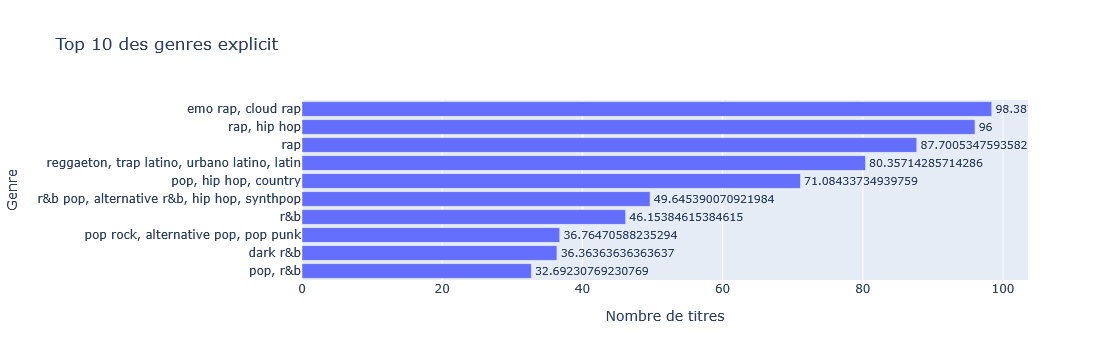

In [35]:
fig = px.bar(
    x=top_10.values,
    y=top_10.index,
    orientation="h",
    title="Top 10 des genres explicit",
    labels={
        "x": "Nombre de titres",
        "y": "Genre"},
    text=top_10.values)

fig.update_layout(
    yaxis={"categoryorder": "total ascending"})
fig.update_traces(textposition="outside")
fig.show()

#